## LPS-induced inflammation differentially affects endogenous Ca2⁺ activity in mouse and human iPSC-derived astrocytes
### Franziska E. Müller, Flavian Ivanov, Anne-Catharine Studt, Ida Nitzsche, Frauke S. Bahr, Anna-Lena Krüger, Josephine Labus, Ghanendra Singh, Evgeni G. Ponimaskin, Kerstin Lenk* & Andre Zeug*
\* authors contributed equally 
Mol Med 32, 52 (2026). https://doi.org/10.1186/s10020-026-01450-3

**Contribution to code:** Ghanendra Singh, Andre Zeug, Kerstin Lenk

**Install libraries if needed:**  
pip install seaborn, used version seaborn-0.13.2  
pip install scikit-learn, used version scikit-learn-1.9.0  
pip install openpyxl, used version openpyxl-3.1.5

In [47]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
import matplotlib.colors as colors
%matplotlib inline
import seaborn as sns
import os

from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
from matplotlib.colors import Normalize

# ML Methods
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, FastICA, NMF
# Importing different scalars
from sklearn.preprocessing import StandardScaler,MinMaxScaler

# Handy to ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Load data from Excel file
#### Note:  
* Place your excel file in the same folder as jupyter notebook or use custom path
* Ignores the first header row for simplicity
* Index starts from zero

In [48]:
# Load data from the excel file into a dataframe using pandas pd
path = 'MLData_comp_LPS_Treatment_Ch2_updated_file.xlsx'
xl = pd.ExcelFile(path)
# Check multipe sheets in the excel file #xl.sheet_names
df_b18_g_5 = xl.parse(1,header=1) # pass sheet index as 1 for 18bin with gamma 0.5 excel data

In [49]:
# Visualize first five observations
df_b18_g_5.head()

,Condition,ExperimentDay,FileNo (fnf),Cond.Label,ExpDay.Label,Ca01_Bin01,Ca01_Bin02,Ca01_Bin03,Ca01_Bin04,Ca01_Bin05,...,Ca06_Bin09.3,Ca06_Bin10.3,Ca06_Bin11.3,Ca06_Bin12.3,Ca06_Bin13.3,Ca06_Bin14.3,Ca06_Bin15.3,Ca06_Bin16.3,Ca06_Bin17.3,Ca06_Bin18.3
0,1,2,1,HIP woT,AC345,0.0,0.0,25.116892,30.186748,8.372297,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,1,2,2,HIP woT,AC345,0.0,0.0,19.268041,0.000000,0.000000,...,5.343993,7.557547,5.343993,11.949532,0.000000,16.899190,29.754094,15.115095,0.0,0.0
2,1,2,3,HIP woT,AC345,0.0,0.0,7.397191,0.000000,0.000000,...,0.000000,0.000000,0.000000,7.397191,25.624623,22.191574,12.812311,0.000000,0.0,0.0
3,1,2,4,HIP woT,AC345,0.0,0.0,12.566127,17.771187,0.000000,...,0.000000,0.000000,0.000000,8.885593,15.390299,8.885593,12.566127,0.000000,0.0,0.0
4,1,2,5,HIP woT,AC345,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.973211,16.727691,0.0,0.0


### Dataframe with multi Index
* Data columm contains (first five sub columns)
* Here it is fixed (metadata size = 5)

In [50]:
# Function to load data with proper columns names
# Default binsize in the function is 18

def load_data(df,bs=18): # bs is bin size in short
    md = 5 #md = 5 as metadata size
    df_xl = pd.concat([df.iloc[:,0:md],
                       df.iloc[:,md:1*bs*6+md],
                       df.iloc[:,1*bs*6+md:2*bs*6+md],
                       df.iloc[:,2*bs*6+md:3*bs*6+md],
                       df.iloc[:,3*bs*6+md:4*bs*6+md]],
                      axis=1,
                      keys=['Data','maxArea','duration','maxDist','slopeCa'])
    return df_xl

### Load the whole data file (HIP, PFC + iPSCs)
* Add the path to iPSCs data

In [51]:
path2 = 'MLData_hiPSC-Astros-AAV-V5-basal_Ch2.xlsx'

xl2 = pd.ExcelFile(path2)
df_b18_g_5_iPSC = xl2.parse(0,header=1)
df = load_data(df_b18_g_5_iPSC, binsize)
df.head()

Data                                                         maxArea  \
  Condition ExperimentDay FileNo (fnf)   Cond.Label ExpDay.Label Ca01_Bin01   
0         1             1            2  WT, wo stim     DIFF006b  63.207156   
1         1             1            3  WT, wo stim     DIFF006b  35.185169   
2         1             1            4  WT, wo stim     DIFF006b  80.246229   
3         1             2            1  WT, wo stim      DIFF008  34.108939   
4         1             2            2  WT, wo stim      DIFF008  59.712760   

                                                 ...      slopeCa  \
  Ca01_Bin02  Ca01_Bin03 Ca01_Bin04  Ca01_Bin05  ... Ca06_Bin09.3   
0  31.603578   22.347104  22.347104   38.706320  ...     0.000000   
1  56.734380   56.734380  15.735286   27.254314  ...    15.735286   
2  61.546048  102.986236  70.173291  119.975334  ...     0.000000   
3  41.774748   34.108939   0.000000   68.217878  ...     0.000000   
4  36.566448   21.111649  21.111649   63.334947  ...     0.000000   

                                                                    \
  Ca06_Bin10.3 Ca06_Bin11.3 Ca06_Bin12.3 Ca06_Bin13.3 Ca06_Bin14.3   
0          0.0          0.0          0.0          0.0          0.0   
1          0.0          0.0          0.0          0.0          0.0   
2          0.0          0.0          0.0          0.0          0.0   
3          0.0          0.0          0.0          0.0          0.0   
4          0.0          0.0          0.0          0.0          0.0   

                                                       
  Ca06_Bin15.3 Ca06_Bin16.3 Ca06_Bin17.3 Ca06_Bin18.3  
0     0.000000          0.0          0.0            0  
1     0.000000          0.0          0.0            0  
2     0.000000          0.0          0.0            0  
3    24.118662          0.0          0.0            0  
4     0.000000          0.0          0.0            0  

[5 rows x 437 columns]

#### Data representation can also be further simplified as 
* Metadata (First five columns) or more for later datasets
* Main data (More no. of features can be considered)
* Generally a single name is used to just modify binsize and run whole cells at once.
* Dataframes are named with bin sizes to ensure to choose right binsize and dataframe.


### Main dataframe

In [52]:
# Always use this bin size
binsize = 18 #default binsize
# change dataframe and binsize for different data
df = load_data(df_b18_g_5, binsize)

### Plotting different x-axis for bin size 18 for flame plots

In [53]:
bins = 18 # binsize
bins_area = np.logspace(np.log10(0.44), np.log10(4000), num=bins, base=10)
bins_duration = np.logspace(np.log10(0.6), np.log10(300), num=bins, base=10)
bins_distance = np.logspace(np.log10(0.5), np.log10(100), num=bins, base=10)
bins_slope = np.logspace(np.log10(0.001), np.log10(8), num=bins, base=10)

x_axis_bins = [bins_area,bins_duration,bins_distance,bins_slope]
y_axis_thresholds = [.5,1,2,5,10,20]

## NMF (Non-Negative Matrix Factorization)

### On entire dataset

In [54]:
# Load data
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

def nmf_whole(nmf_Comp=6, plot_contour_flag=True, region="Whole_data"):

    # df = load_data(df_b18_g_5)
    df = load_data(df_b18_g_5, 18)
    features = ["maxArea", "duration", "maxDist", "slopeCa"]
    legend_names = ["Ctrl.", "3 h LPS", "24 h LPS"]
    if region == "HIP":
        dfc = df[df["Data"]["Condition"] <= 3]

    elif region == "PFC":
        dfc = df[df["Data"]["Condition"] > 3]
    elif region == "iPSC":
        dfc = load_data(df_b18_g_5_iPSC, 18)
        print("iPSC data loaded")
    else:
        dfc = df

    X = dfc.iloc[:, 5:]  # data (ignore first five columns)
    y = dfc.iloc[:, 0]  # labels
    nmfC = nmf_Comp  # of NMF components
    nF = 4  # no. of features

    nmf = NMF(n_components=nmfC, init="random", random_state=0, tol=1e-3)
    W = nmf.fit_transform(X)
    H = nmf.components_
    # Normalize H to have a maximum value of 1 and adjust W accordingly
    W = W * H.max(axis=1)
    H = H / H.max(axis=1, keepdims=True)
    # Manually reorganize matrices to fit color sceme
    if region == "HIP":
        if nmf_Comp == 2:
            H = H[[1, 0], :]
            W = W[:, [1, 0]]
        # elif nmf_Comp == 3:
        #     H = H[[0, 2, 1], :]
        #     W = W[:, [0, 2, 1]]
    elif region == "iPSC":
        # if nmf_Comp == 2:
        #     H = H[[1, 0], :]
        #     W = W[:, [1, 0]]
        if nmf_Comp == 3:
            H = H[[0, 2, 1], :]
            W = W[:, [0, 2, 1]]
    # print(H[:5, :5])
    # print(H_reorganized[:5, :5])
    
    
    H = H.reshape(nmfC, 4, 6, 18)
    vmin = 0
    vmax = 1  # H.max()
    levels = np.linspace(vmin, vmax, 11)  # Define levels for contourf
    levelsC = np.linspace(0.2, vmax, 6)  # Define levels for contour
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    # Generate a timestamp
    timestamp = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
    
    # Create a PdfPages object with a timestamped file name
    file_name = f'tmp/NMF_{region}_{nmf_Comp}_{timestamp}.pdf'
    file_name_W = f'tmp/NMF_{region}_{nmf_Comp}_{timestamp}_W.csv'
    # Convert W to a DataFrame
    W_df = pd.DataFrame(W)
    # Save the DataFrame to a CSV file
    W_df.to_csv(file_name_W, index=False)
    #print("W matrix saved as:", file_name_W)
    # Set the default font size
    plt.rcParams.update({'font.size': 16})  # Change 16 to your desired font size

    feature_labels = [r"MaxSize [$\mu$m$^2$]",
        "Duration [s]",
        r"Distance [$\mu$m]",
        r"Ca$^{2+}$ change [a.u.]"
    ]

    legend_names = ["Ctrl.", "3 h LPS", "24 h LPS"]
    
    with PdfPages(file_name) as pdf:

        ## Contours overlayed on top of each other
        cmap = ["Greys", "Greens", "Reds", "Blues", "Purples", "Oranges"]
        res = plt.subplots(1, nF+1, figsize=(18, 4),facecolor='none')
        axes : list[plt.Axes] = res[1]  # Initialize axes list
        fig2 = res[0]
        for f in range(nF):
            sax = plt.subplot(1, nF+1, f + 1)
            for nmf_i in range(nmfC):
                contour = plt.contour(x_axis_bins[f], range(0, 6, 1), H[nmf_i, f], levels=levelsC, 
                                        vmin=vmin, vmax=vmax, extend="neither", cmap=cmap[nmf_i], 
                                        alpha=0.7, linewidths=3, norm=norm)
                # fp.cmap.set_over('black')
                # fp.cmap.set_under('white')
                plt.xscale("log")  # Set x-axis to logarithmic scale
                plt.yticks(range(0, 6, 1), y_axis_thresholds)
                plt.xlim(x_axis_bins[f].min(), x_axis_bins[f].max())  # Set x-axis limits
                # plt.autoscale(enable=True, axis='x', tight=True)
                # contour.set_clim(vmin, vmax)  # Set colorbar limits explicitly
                contour.cmap.set_under("white")
                # plt.title(features[f], pad=20)
                plt.ylabel("Threshold (NMF Comp. %d)" % (nmf_i + 1),fontsize=15)
                plt.xlabel(feature_labels[f],fontsize=15)
            sax.patch.set_alpha(0)  # Make the axes background transparent
            plt.tight_layout()
            sax.set_aspect(aspect="auto")  # Options: 'equal', 'auto', or a numeric value
        # plt.show()

        # Weight distribution
        cmap=["grey","green","red","blue","purple","orange"]
        clabel = dfc["Data"]["Cond.Label"].unique()
        cond_u = dfc["Data"]["Condition"].unique()
        cond_u_int = list(map(int, cond_u))
        WW = np.zeros((cond_u.shape[0], nmfC))
        list_cond = []
        for i,cond_i in enumerate(cond_u):
            W_i = W[dfc["Data"]["Condition"] == cond_i, :]
            list_cond.append(W_i)
            W_i = np.mean(W_i, axis=0)
            WW[i, :] = W_i
        # list_cond[0][:,0]
        # plt.figure(figsize=(12, 6))
        
        plt.subplot(1, nF+1, nF + 1)
        for i in range(WW.shape[1]):  # Loop over the number of NMF components
            plt.plot(cond_u,WW[:,i],ls="--",marker="s",
                    label=f"NMF Comp{i+1}", color=cmap[i % len(cmap)])  # Use colors from cmap
        # plt.legend()
        plt.title("Weight Distribution", pad=20)
        plt.xticks(cond_u,legend_names)
        plt.xlabel("Condition Index")
        plt.ylabel("Weight")
        plt.ylim(bottom=0)
        plt.gca().patch.set_alpha(0)  # Make the axes background transparent#
        plt.savefig("tmp/NMF_Weight_Distribution_%d.svg"%nmfC, dpi=300, bbox_inches='tight', transparent=True)
        plt.show()
        #pdf.savefig(fig2, transparent=True)  # Save the current figure to the PDF
        

In [ ]:
from datetime import datetime

def nmf_whole(nmf_Comp=6, plot_contour_flag=True, region="Whole_data",suptext="", suptextcolor=""):

    # Load data
    df = load_data(df_b18_g_5, 18)

    if region == "HIP":
        dfc = df[df["Data"]["Condition"] <= 3]

    elif region == "PFC":
        dfc = df[df["Data"]["Condition"] > 3]

    elif region == "iPSC":
        dfc = load_data(df_b18_g_5_iPSC, 18)
        #print("iPSC data loaded")

    else:
        dfc = df

    # Labels
    feature_labels = [r"MaxSize [$\mu$m$^2$]","Duration [s]",r"Distance [$\mu$m]",r"Ca$^{2+}$ change [a.u.]",]
    legend_names = ["Ctrl.", "3 h LPS", "24 h LPS"]

    # NMF
    X = dfc.iloc[:, 5:] 
    nmf = NMF(n_components=nmf_Comp,init="random",random_state=0,tol=1e-3,)

    W = nmf.fit_transform(X)
    H = nmf.components_

    # Normalize
    W = W * H.max(axis=1)
    H = H / H.max(axis=1, keepdims=True)

    # Optional component reordering
    if region == "HIP" and nmf_Comp == 2:
        H = H[[1, 0], :]
        W = W[:, [1, 0]]

    elif region == "iPSC" and nmf_Comp == 3:
        H = H[[0, 2, 1], :]
        W = W[:, [0, 2, 1]]

    # Save W matrix
    timestamp = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
    pd.DataFrame(W).to_csv(f"tmp/NMF_{region}_{nmf_Comp}_{timestamp}_W.csv",index=False,)

    # Reshape H
    H = H.reshape(nmf_Comp, 4, 6, 18)

    vmin, vmax = 0, 1
    levelsC = np.linspace(0.2, vmax, 6)

    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    # Figure layout
    plt.rcParams.update({"font.size": 14})

    fig, axes = plt.subplots(1,5,figsize=(16, 4),constrained_layout=True,)

    contour_cmaps = ["Greys","Greens","Reds","Blues","Purples","Oranges",]

    # Contour plots (first 4 columns)
    y_axis_thresholds = [0.5, 1, 2, 5, 10, 20]
    for f in range(4):

        ax = axes[f]
        for nmf_i in range(nmf_Comp):

            contour = ax.contour(x_axis_bins[f],range(6),H[nmf_i, f],levels=levelsC,cmap=contour_cmaps[nmf_i],
                                 alpha=0.7,linewidths=3,norm=norm,)

            contour.cmap.set_under("white")

        ax.set_xscale("log")
        ax.set_xlim(x_axis_bins[f].min(),x_axis_bins[f].max(),)
        ax.set_xlabel(feature_labels[f])        

        ax.set_yticks(range(6))

        if f == 0:
            ax.set_yticks(range(6))
            ax.set_yticklabels(y_axis_thresholds)
            ax.tick_params(axis="y", labelleft=True)
            ax.set_ylabel(r"$Ca^{2+}$ threshold")
        
        
        # Force x ticks to show on log scale
        ax.tick_params(axis="x", which="both", labelbottom=True)
        ax.set_aspect("auto")

    fig.supylabel(suptext, color=suptextcolor,fontsize=16, fontweight="bold")
    
    # Weight distribution (last column)
    ax_w = axes[4]

    cmap_weights = ["grey","green","red","blue","purple","orange",]
    cond_u = dfc["Data"]["Condition"].unique()
    
    WW = np.zeros((len(cond_u), nmf_Comp))
    for i, cond_i in enumerate(cond_u):
        W_i = W[dfc["Data"]["Condition"] == cond_i]
        WW[i] = np.mean(W_i, axis=0)

    for i in range(nmf_Comp):

        ax_w.plot(cond_u,WW[:, i],ls="--",marker="s",color=cmap_weights[i % len(cmap_weights)],label=f"NMF {i + 1}",)

    ax_w.set_xticks(cond_u)
    ax_w.set_xticklabels(legend_names)

    ax_w.set_xlabel("Condition")
    ax_w.set_ylabel("Weight")
    ax_w.set_ylim(bottom=0)
    ax_w.tick_params(axis="x", which="both", labelbottom=True)
    ax_w.tick_params(axis="y", which="both", labelleft=True)

    ax_w.legend(frameon=False)

    # Export
    #plt.savefig(f"tmp/NMF_{region}_{nmf_Comp}.svg",dpi=300,bbox_inches="tight",transparent=True)

    plt.show()

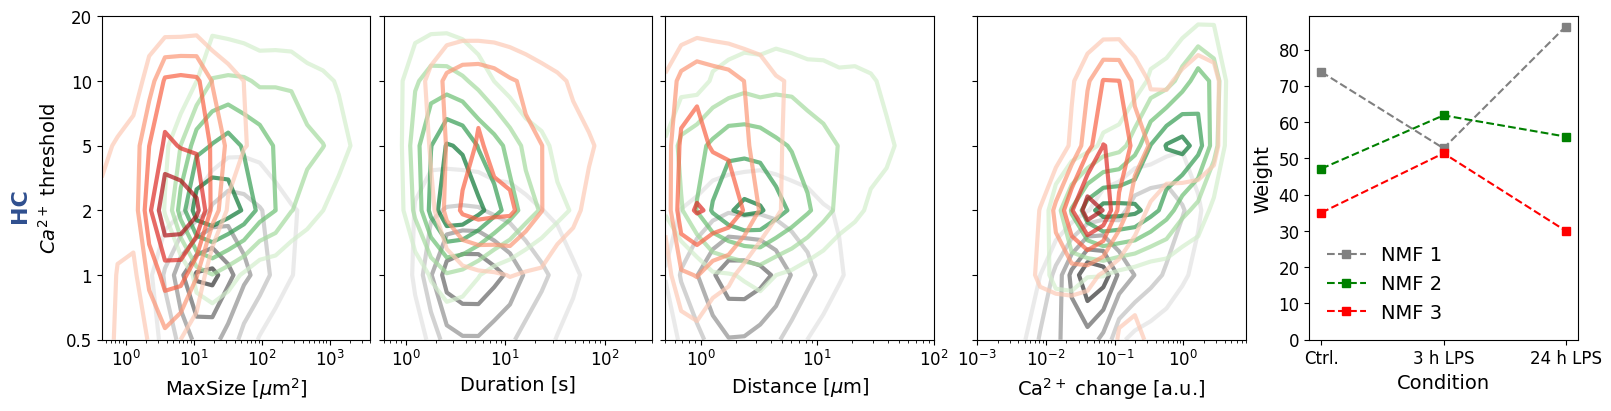

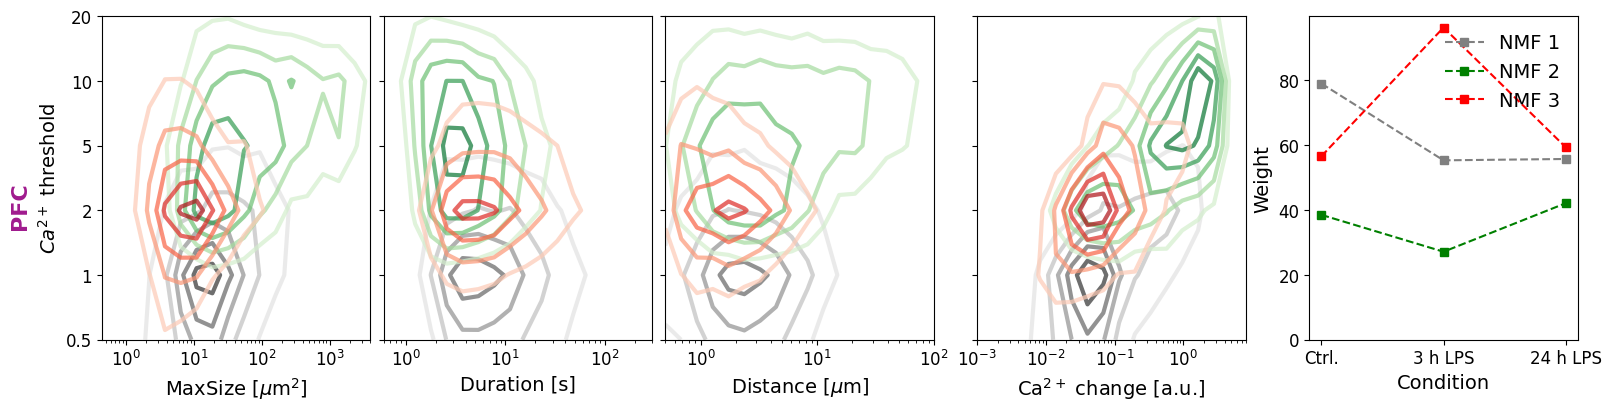

iPSC data loaded


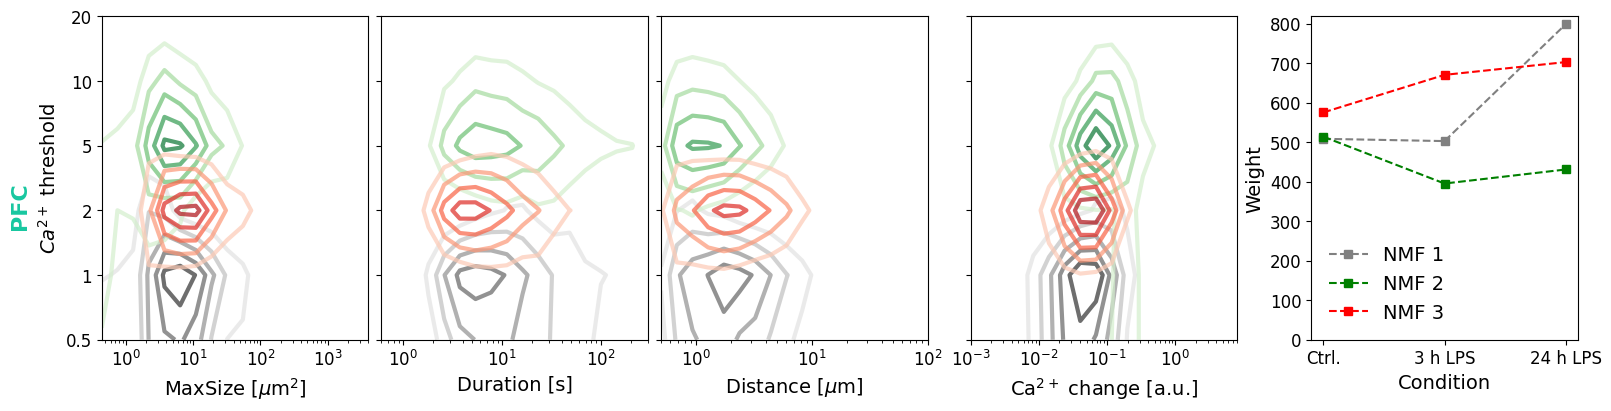

In [61]:
os.makedirs("tmp", exist_ok=True)
nmf_whole(nmf_Comp=3, plot_contour_flag=True, region="HIP", suptext="HC", suptextcolor="#2F4F8F")
nmf_whole(nmf_Comp=3, plot_contour_flag=True, region="PFC", suptext="PFC",suptextcolor="#A01B8E")
nmf_whole(nmf_Comp=3, plot_contour_flag=True, region="iPSC", suptext="PFC",suptextcolor="#18C7A0")

## PCA, NMF and LDA

In [57]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
def lda_compare(region="Whole_data"):

    # df = load_data(df_b18_g_5)
    features = ["maxArea", "duration", "maxDist", "slopeCa"]
    legend_names = ["Ctrl.", "3 h LPS", "24 h LPS"]

    if region == "HIP":
        df = load_data(df_b18_g_5, 18)
        dfc = df[df["Data"]["Condition"] <= 3]
        colors_rgb = [(144, 191, 249), (139, 144, 206), (0, 0, 192)]  # RGB colors
    elif region == "PFC":
        df = load_data(df_b18_g_5, 18)
        dfc = df[df["Data"]["Condition"] > 3]
        colors_rgb = [(255, 160, 160), (193, 139, 183), (128, 0, 128)]  # RGB colors
    elif region == "iPSC":
        dfc = load_data(df_b18_g_5_iPSC, 18)
        print("iPSC data loaded")
        colors_rgb = [(169, 254, 169), (15, 153, 178), (3, 78, 97)]  # RGB colors
    else:
        df = load_data(df_b18_g_5, 18)
        dfc = df
    
    colors_rgb = np.array(colors_rgb) / 255.0  # Normalize RGB values to [0, 1]
    X = dfc.iloc[:, 5:]  # data (ignore first five columns)
    y = dfc.iloc[:, 0]  # labels

    noC = 2 # no. of components

    lda = LDA(n_components=noC) #,shrinkage='Auto',solver='lsqr',priors=None,store_covariance=False, tol=0.0001
    pca = PCA(n_components=noC,random_state=22)

    #nmf = NMF(n_components=noC)
    nmf = NMF(n_components=noC, init='random', random_state=22)

    Xs = StandardScaler().fit_transform(X)
    Xs = MinMaxScaler().fit_transform(X)

    X_lda = lda.fit_transform(X,y)
    X_pca = pca.fit_transform(X)
    X_nmf = nmf.fit_transform(X)

    # Define RGB colors for each condition
    unique_conditions = np.unique(y)
    color_map = {condition: colors_rgb[i % len(colors_rgb)] for i, condition in enumerate(unique_conditions)}
    condition_colors = [color_map[condition] for condition in y]

    # Generate a timestamp
    timestamp = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
    # Create a PdfPages object with a timestamped file name
    file_name = f'tmp/LDA_{region}.pdf' #_{timestamp}
    with PdfPages(file_name) as pdf:
        res = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=False)
        axes : list[plt.Axes] = res[1]  # Initialize axes list
        fig = res[0]
        print("Default font size:", plt.rcParams['font.size'])
        adjusted_font_size = plt.rcParams['font.size']-2  # Adjust font size for legends
        
        # PCA scatter plot
        for i, condition in enumerate(unique_conditions):
            mask = y == condition
            axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=color_map[condition], label=legend_names[i])
        axes[0].set_title('PCA')
        axes[0].set_xlabel('PCA 1')
        axes[0].set_ylabel('PCA 2')
        axes[0].set_aspect('equal')  # Set equal scaling
        axes[0].legend(fontsize=adjusted_font_size)

        # NMF scatter plot
        for i, condition in enumerate(unique_conditions):
            mask = y == condition
            axes[1].scatter(X_nmf[mask, 0], X_nmf[mask, 1], color=color_map[condition], label=legend_names[i])
        axes[1].set_title('NMF')
        axes[1].set_xlabel('NMF 1')
        axes[1].set_ylabel('NMF 2')
        axes[1].set_aspect('equal')  # Set equal scaling
        axes[1].legend(fontsize=adjusted_font_size)

        # LDA scatter plot
        for i, condition in enumerate(unique_conditions):
            mask = y == condition
            axes[2].scatter(X_lda[mask, 0], X_lda[mask, 1], color=color_map[condition], label=legend_names[i])
        axes[2].set_title('LDA')
        axes[2].set_xlabel('LDA 1')
        axes[2].set_ylabel('LDA 2')
        axes[2].set_aspect('equal')  # Set equal scaling , adjustable='box'
        axes[2].legend(fontsize=adjusted_font_size)
        
        # Add legend
        axes[2].legend(loc='best', fontsize='small', framealpha=0.5, borderaxespad=0.2,handletextpad=0.2) #, edgecolor='black'
        #axes[2].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small', framealpha=0.5, borderaxespad=0.2) #, edgecolor='black'
        
        # Adjust layout for better spacing  
        plt.tight_layout()
        plt.show()
        pdf.savefig(fig)

Default font size: 14.0


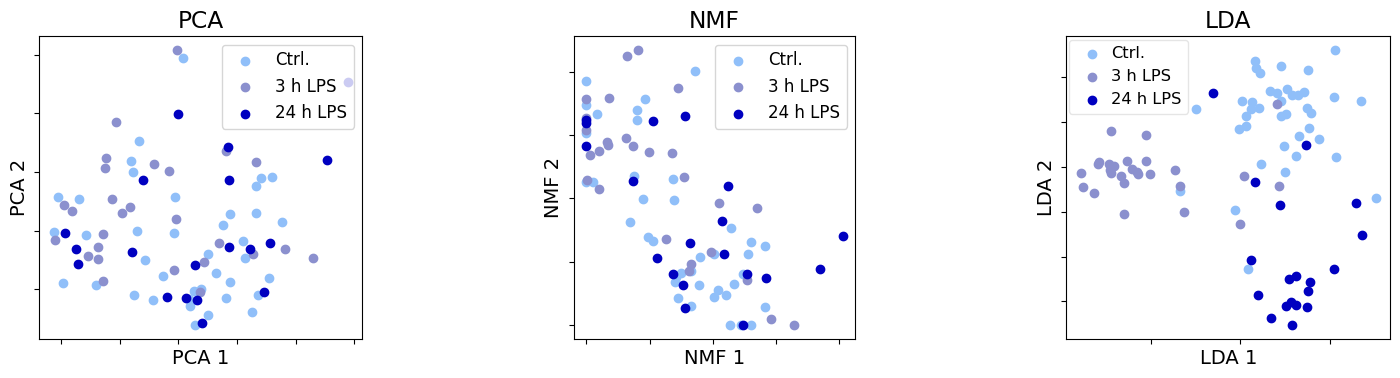

In [58]:
lda_compare('HIP')

Default font size: 14.0


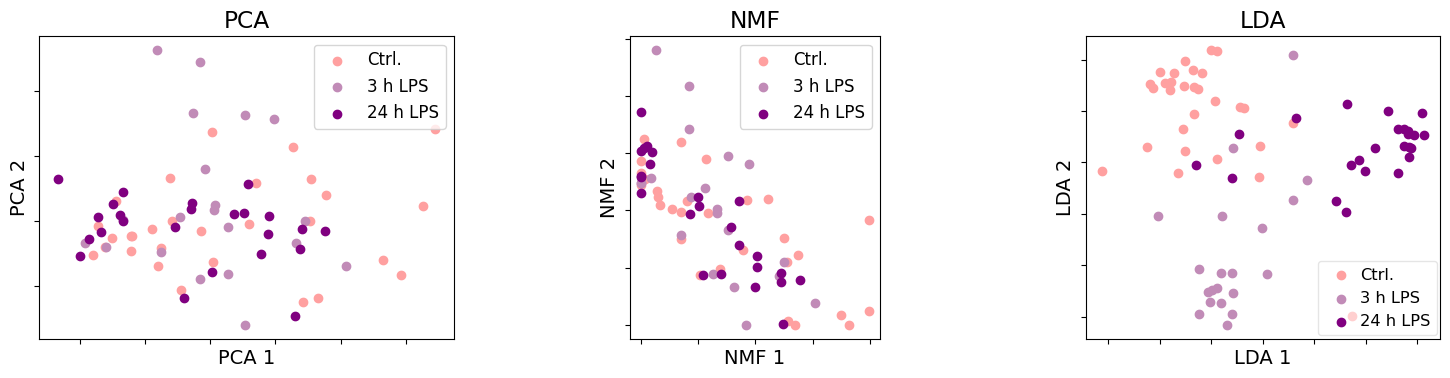

In [59]:
lda_compare('PFC')

## Supplementary Figure 8

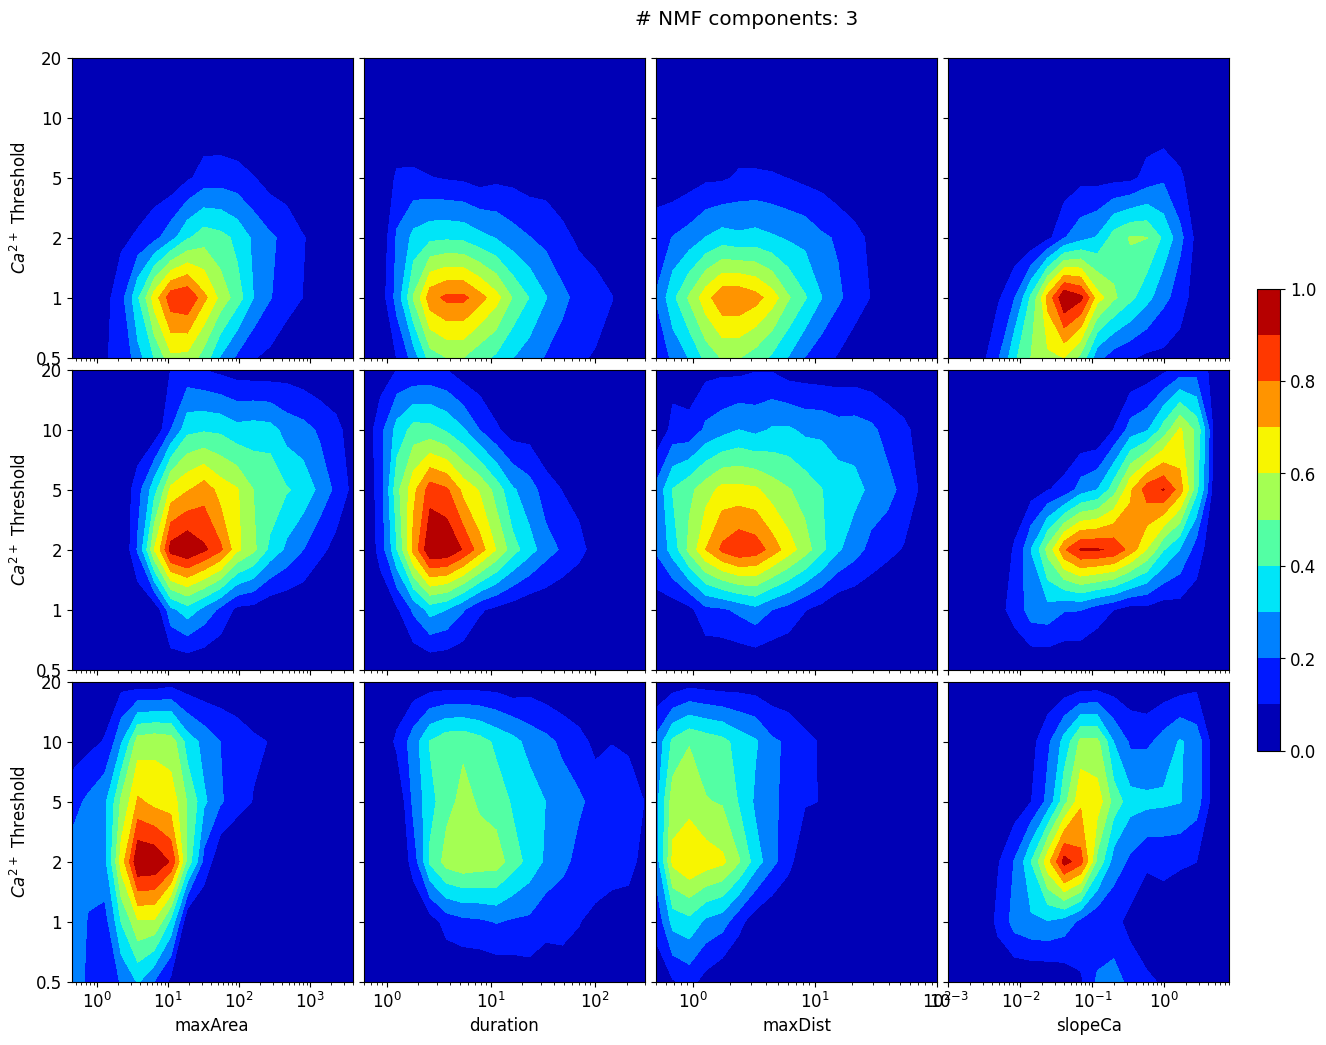

In [60]:
# load data
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
from matplotlib.colors import Normalize

def nmf_whole_modified(nmf_Comp=6, plot_contour_flag=True, region="Whole_data"):

    # df = load_data(df_b18_g_5)
    df = load_data(df_b18_g_5, 18)
    features = ["maxArea", "duration", "maxDist", "slopeCa"]
    legend_names = ["Ctrl.", "3 h LPS", "24 h LPS"]
    if region == "HIP":
        dfc = df[df["Data"]["Condition"] <= 3]

    elif region == "PFC":
        dfc = df[df["Data"]["Condition"] > 3]
    elif region == "iPSC":
        dfc = load_data(df_b18_g_5_iPSC, 18)
        print("iPSC data loaded")
    else:
        dfc = df

    X = dfc.iloc[:, 5:]  # data (ignore first five columns)
    y = dfc.iloc[:, 0]  # labels
    nmfC = nmf_Comp  # of NMF components
    nF = 4  # no. of features

    nmf = NMF(n_components=nmfC, init="random", random_state=0, tol=1e-3)
    W = nmf.fit_transform(X)
    H = nmf.components_
    # Normalize H to have a maximum value of 1 and adjust W accordingly
    W = W * H.max(axis=1)
    H = H / H.max(axis=1, keepdims=True)
    # Manually reorganize matrices to fit color sceme
    if region == "HIP":
        if nmf_Comp == 2:
            H = H[[1, 0], :]
            W = W[:, [1, 0]]
        # elif nmf_Comp == 3:
        #     H = H[[0, 2, 1], :]
        #     W = W[:, [0, 2, 1]]
    elif region == "iPSC":
        # if nmf_Comp == 2:
        #     H = H[[1, 0], :]
        #     W = W[:, [1, 0]]
        if nmf_Comp == 3:
            H = H[[0, 2, 1], :]
            W = W[:, [0, 2, 1]]
    # print(H[:5, :5])
    # print(H_reorganized[:5, :5])
    
    
    H = H.reshape(nmfC, 4, 6, 18)
    vmin = 0
    vmax = 1  # H.max()
    levels = np.linspace(vmin, vmax, 11)  # Define levels for contourf
    levelsC = np.linspace(0.2, vmax, 6)  # Define levels for contour
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    # Generate a timestamp
    timestamp = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
    # Create a PdfPages object with a timestamped file name
    file_name = f'tmp/NMF_{region}_{nmf_Comp}_{timestamp}.pdf'
    file_name_W = f'tmp/NMF_{region}_{nmf_Comp}_{timestamp}_W.csv'
    # Convert W to a DataFrame
    W_df = pd.DataFrame(W)
    
    # Save the DataFrame to a CSV file
    #W_df.to_csv(file_name_W, index=False)
    #print("W matrix saved as:", file_name_W)
    
    # Set the default font size
    plt.rcParams.update({'font.size': 12})  # Change 16 to your desired font size
    plt.rcParams['xtick.labelsize']=12
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['xtick.labelbottom'] = False
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.labelleft'] = False
    plt.rcParams['ytick.labelsize']=12
    
    with PdfPages(file_name) as pdf:
        #fig1 = plt.figure(figsize=(18,12))
        res = plt.subplots(nmfC,nF, figsize=(18,nmfC*4),sharex=False, sharey=True)
        axes1 : list[plt.Axes] = res[1]  # Initialize axes list
        fig1 = res[0]
        
        plt.suptitle("# NMF components: %d"%nmfC, y=0.92)  # Adjust the y parameter for more space
        
        #plt.subplots_adjust(top=0.95)  # Adjust the top spacing for more gap
        for nmf_i in range(nmfC):
            for f in range(nF):
                plt.subplot(nmfC,nF,nF*nmf_i +f+1)
                if plot_contour_flag:
                    contour = plt.contourf(x_axis_bins[f],range(0,6,1),H[nmf_i,f],cmap='jet',levels=levels,
                                vmin=vmin,vmax=vmax, extend='neither')
                else:
                    contour = plt.imshow(H[nmf_i,f], interpolation='bicubic',aspect='auto',
                                        origin='lower',cmap='jet',vmin=0)

                contour.set_clim(vmin, vmax)  # Set colorbar limits explicitly
        
                if f==0:
                    plt.tick_params(left=True,labelleft=True)
                    plt.ylabel(r'$Ca^{2+}$ Threshold')                    
                
                if nmf_i == nmfC-1:
                    plt.tick_params(bottom=True,labelbottom=True)
                    plt.xlabel(features[f])
                
                #fp.cmap.set_over('black')
                #fp.cmap.set_under('white')
                
                plt.xscale('log')  # Set x-axis to logarithmic scale
                plt.yticks(range(0,6,1),y_axis_thresholds,fontsize=15)
                #plt.xlim(x_axis_bins[f].min(), x_axis_bins[f].max())  # Set x-axis limits
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)
                plt.autoscale(enable=True, axis='x', tight=True)
                
        plt.subplots_adjust(hspace=0.04,wspace=0.04)
        cbar = fig1.colorbar(contour,ax=axes1.ravel().tolist(),shrink=0.5,pad=0.02) # ,fontsize=15
        cbar.mappable.set_clim(vmin, vmax)  # Set colorbar limits explicitly
        #fig1.tight_layout()
        
        plt.gca().patch.set_alpha(0)  # Make the axes background transparent#
        pdf.savefig(fig1)  # Save the current figure to the PDF
        #plt.savefig("NMF_Components_%d.pdf"%nmfC, dpi=300, bbox_inches='tight')
        plt.savefig('NMF_Components_%d_iPSC.svg'%nmfC,format="svg", dpi=600, bbox_inches='tight',transparent=True)
        plt.show()

n_nmfc=3
nmf_whole_modified(n_nmfc,plot_contour_flag=True,region = "HIP")